In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1.Define the sectors + start date

In [2]:
tickers = {
    "Technology": "XLK",
    "Energy": "XLE",
    "Financials": "XLF"
}

start_date = "2015-01-01"

# 2.Download prices

In [3]:
prices_raw = yf.download(
    list(tickers.values()),
    start=start_date,
    auto_adjust=True,
    progress=False
)

prices_raw.head()

Price           Close                             High                        \
Ticker            XLE        XLF        XLK        XLE        XLF        XLK   
Date                                                                           
2015-01-02  25.365135  16.217978  18.062744  25.448060  16.329464  18.255319   
2015-01-05  24.315819  15.876956  17.787012  25.020671  16.145835  17.997095   
2015-01-06  23.958620  15.634313  17.572554  24.472110  15.929422  17.839532   
2015-01-07  24.009651  15.798262  17.721348  24.354105  15.837609  17.765114   
2015-01-08  24.548653  16.034349  18.110880  24.606062  16.073699  18.150270   

Price             Low                             Open                        \
Ticker            XLE        XLF        XLK        XLE        XLF        XLK   
Date                                                                           
2015-01-02  24.998356  16.093376  17.970833  25.109986  16.303232  18.211553   
2015-01-05  24.191433  15.837608  17.734492  25.011103  16.113045  17.997095   
2015-01-06  23.789581  15.562175  17.489395  24.274368  15.876958  17.839532   
2015-01-07  23.850182  15.673659  17.594422  24.248855  15.765470  17.708217   
2015-01-08  24.105329  15.949096  17.839522  24.204199  15.981886  17.865783   

Price         Volume                      
Ticker           XLE       XLF       XLK  
Date                                      
2015-01-02  55498200  40511471  16990400  
2015-01-05  90790400  50770502  14389400  
2015-01-06  83753200  57454463  17491200  
2015-01-07  62384800  36287049  13069200  
2015-01-08  56373800  37995923  28423400

In [4]:
prices = prices_raw["Close"]

prices.head()

Ticker,XLE,XLF,XLK
Date,,,
2015-01-02,25.365135,16.217978,18.062744
2015-01-05,24.315819,15.876956,17.787012
2015-01-06,23.958620,15.634313,17.572554
2015-01-07,24.009651,15.798262,17.721348
2015-01-08,24.548653,16.034349,18.110880


In [5]:
prices = prices.rename(columns={v: k for k, v in tickers.items()})

prices.head()

Ticker,Energy,Financials,Technology
Date,,,
2015-01-02,25.365135,16.217978,18.062744
2015-01-05,24.315819,15.876956,17.787012
2015-01-06,23.958620,15.634313,17.572554
2015-01-07,24.009651,15.798262,17.721348
2015-01-08,24.548653,16.034349,18.110880


In [6]:
prices = prices.dropna()

prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2895 entries, 2015-01-02 to 2026-07-09
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Energy      2895 non-null   float64
 1   Financials  2895 non-null   float64
 2   Technology  2895 non-null   float64
dtypes: float64(3)
memory usage: 90.5 KB


# 3.Calculate Daily returns

In [7]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,Energy,Financials,Technology
Date,,,
2015-01-05,-0.041368,-0.021027,-0.015265
2015-01-06,-0.014690,-0.015283,-0.012057
2015-01-07,0.002130,0.010486,0.008467
2015-01-08,0.022449,0.014944,0.021981
2015-01-09,-0.007925,-0.013497,-0.003142


In [8]:
wealth = (1 + returns).cumprod()

wealth.head()

Ticker,Energy,Financials,Technology
Date,,,
2015-01-05,0.958632,0.978973,0.984735
2015-01-06,0.944549,0.964011,0.972862
2015-01-07,0.946561,0.974120,0.981099
2015-01-08,0.967811,0.988677,1.002665
2015-01-09,0.960141,0.975334,0.999515


# 4.Running Peak

In [9]:
running_peak = wealth.cummax()

running_peak.head()

Ticker,Energy,Financials,Technology
Date,,,
2015-01-05,0.958632,0.978973,0.984735
2015-01-06,0.958632,0.978973,0.984735
2015-01-07,0.958632,0.978973,0.984735
2015-01-08,0.967811,0.988677,1.002665
2015-01-09,0.967811,0.988677,1.002665


# 5.Drawdowns

drawdowns = wealth / running_peak - 1

drawdowns.head()

In [11]:
max_drawdown = drawdowns.min()

max_drawdown

Ticker
Energy       -0.668131
Financials   -0.428625
Technology   -0.335591
dtype: float64

In sector, maximum draqdown is hevly macro dependent, the USA Energy sector suffered the bigger lost from the highest point 

# 6.Create the summary table

In [12]:
import matplotlib.ticker as mtick

max_drawdown = drawdowns.min()

annualized_volatility = returns.std() * (252 ** 0.5)

average_drawdown = drawdowns.mean()

time_under_water = (drawdowns < 0).mean()

summary = pd.DataFrame({
    "Annualized Volatility": annualized_volatility,
    "Maximum Drawdown": max_drawdown,
    "Average Drawdown": average_drawdown,
    "Time Under Water": time_under_water
})

summary

,Annualized Volatility,Maximum Drawdown,Average Drawdown,Time Under Water
Ticker,,,,
Energy,0.291514,-0.668131,-0.146670,0.965100
Financials,0.217041,-0.428625,-0.074872,0.921562
Technology,0.239798,-0.335591,-0.055604,0.848998


With this table, with have a much more complete view, despite the max drdwn, the actual time under water was similiar detween the 3 sectors

# 7.Drawdown curves

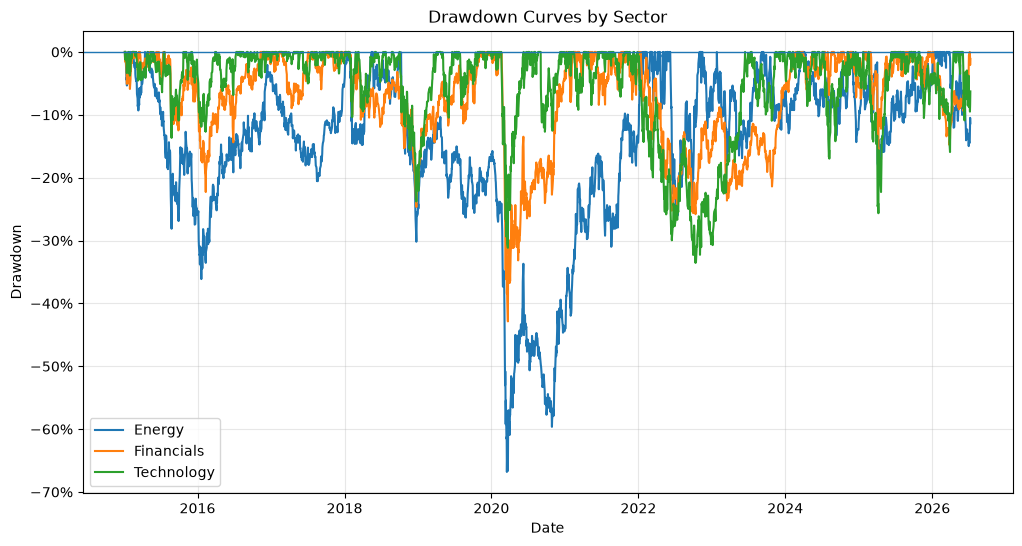

In [13]:
plt.figure(figsize=(12, 6))

for sector in drawdowns.columns:
    plt.plot(drawdowns.index, drawdowns[sector], label=sector)

plt.axhline(0, linewidth=1)

plt.title("Drawdown Curves by Sector")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Obviously during COVID we have the big drawdowns, with this view we can see a little bit of correlation drowdown between the three sectors